# MLP-Classification

In [1]:
import numpy as np
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
import pandas as pd
from keras import ops
from matplotlib.ticker import (MultipleLocator,FormatStrFormatter)
def to_categorical(y, num_classes=None):
    y = ops.convert_to_tensor(y, dtype="int32")
    if num_classes is None:
        num_classes = int(ops.max(y)) + 1
    return ops.one_hot(y, num_classes)

In [2]:
trainData = pd.read_csv("mnist_train.zip")
testData = pd.read_csv("mnist_test.zip")
Xtrain, Ytrain = trainData.iloc[:,1:].to_numpy(), trainData.iloc[:, 0].to_numpy()
Xtest, Ytest = testData.iloc[:,1:].to_numpy(), testData.iloc[:, 0].to_numpy()
Xtrain[2,1]

0

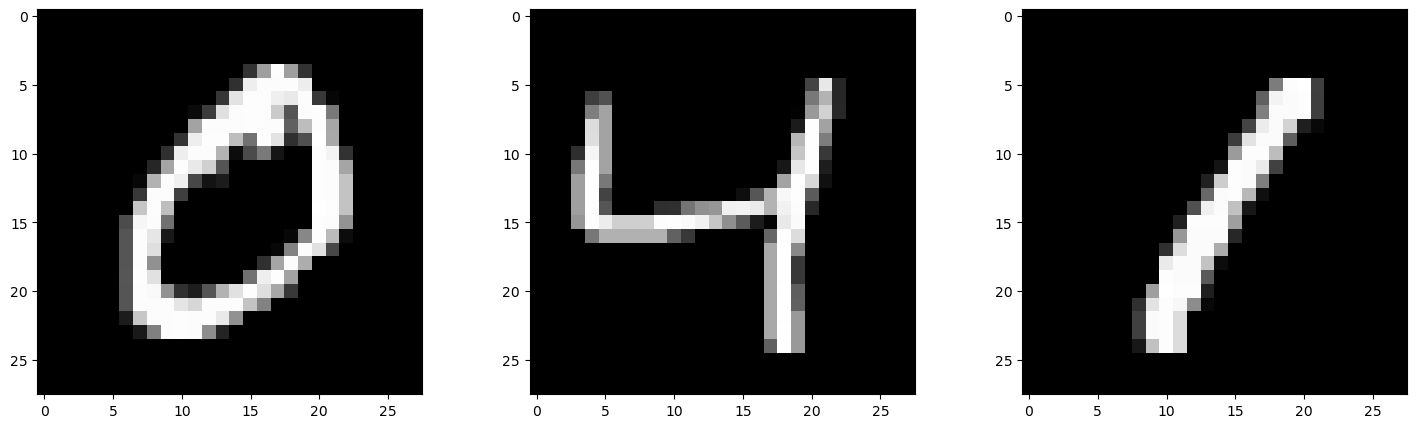

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize = (18,5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.axis(True)
    plt.imshow(np.reshape(Xtrain[i], (28,28)), cmap = "gray")
    plt.subplots_adjust(wspace=0.2, hspace = 0.2)

In [4]:
Xtrain = Xtrain.astype("float32")/255
Xtest = Xtest.astype("float32")/255

In [5]:
Ytrain = to_categorical(Ytrain)
Ytest = to_categorical(Ytest)

In [6]:
Ytrain[1]

tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [7]:
model = keras.Sequential([
    keras.layers.Input(shape = (Xtrain.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')        # gets several integers and returns a percantage with sum of 1
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    loss = keras.losses.CategoricalCrossentropy(),      # Negative sum of y_ilogP_ij
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),       # Momentom Acceleration better than Gradient Descent
    metrics = [keras.metrics.CategoricalAccuracy(name = "accuracy")]
)

In [ ]:
trainState = model.fit(
    Xtrain,
    Ytrain,
    batch_size = 8,     # batch size is a number of samples processed before the model is updated
    epochs = 20,        # the number of complete passes through the training dataset
    validation_split = 0.15
    
)

Epoch 1/20
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.8941 - loss: 0.3581 - val_accuracy: 0.9598 - val_loss: 0.1254
Epoch 2/20
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9659 - loss: 0.1071 - val_accuracy: 0.9726 - val_loss: 0.0968
Epoch 3/20
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9766 - loss: 0.0741 - val_accuracy: 0.9753 - val_loss: 0.0893
Epoch 4/20
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9815 - loss: 0.0575 - val_accuracy: 0.9759 - val_loss: 0.0925
Epoch 5/20
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9851 - loss: 0.0470 - val_accuracy: 0.9770 - val_loss: 0.0878
Epoch 6/20
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9862 - loss: 0.0404 - val_accuracy: 0.9753 - val_loss: 0.1037
Epoch 7/20
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9884 - loss: 0.0342 - val_accuracy: 0.9706 - val_loss: 0.1228
Epoch 8/20
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9902 - loss: 0

In [ ]:
def plot_results(metrics, title=None, ylabel=None, ylim=None, metric_name=None, color=None):
    
    fig, ax = plt.subplots(figsize=(15, 4))
    if not(isinstance(metric_name, list)or isinstance(metric_name, tuple)):
        metrics = [metrics,]
        metric_name = [metric_name,]
        
    for idx, metric in enumerate(metrics):
        ax.plot(metric, label=metric_name[idx], color=color[idx])
    
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim([0, 20])
    plt.ylim(ylim)
    
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_major_locator(MultipleLocator(1))
    plt.legend()
    plt.grid("True")
    plt.show

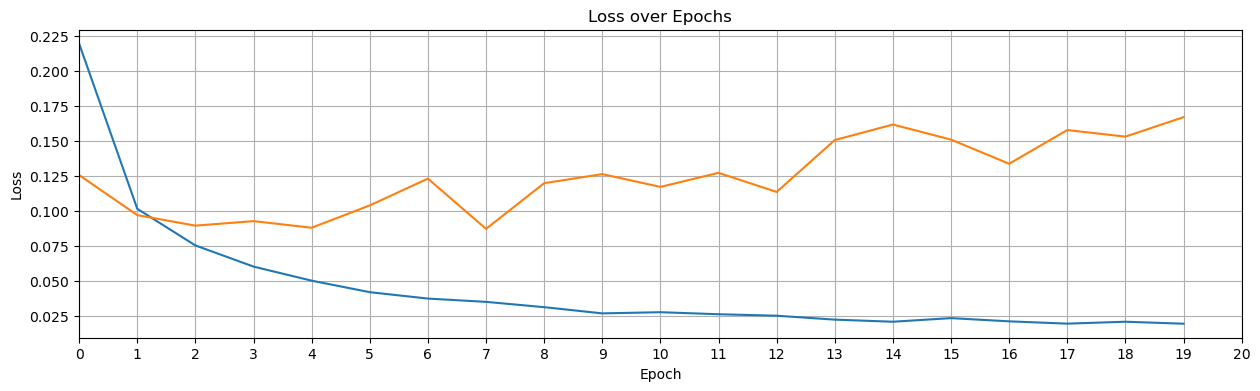

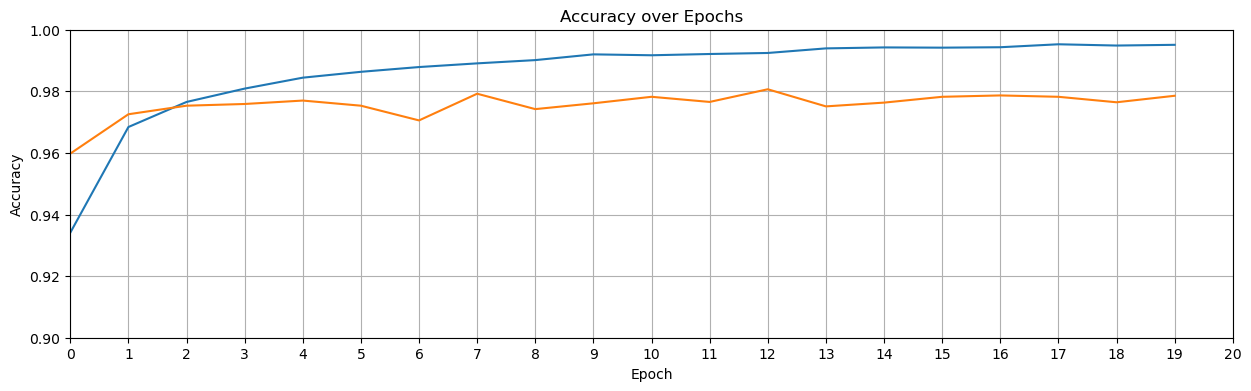

In [11]:
# Plot training vs validation loss
plot_results(
  [trainState.history['loss'], trainState.history['val_loss']],
  title='Loss over Epochs',
  ylabel='Loss',
  ylim=None,
  metric_name=['loss', 'val_loss'],
  color=['tab:blue', 'tab:orange']
)

# Plot training vs validation accuracy
plot_results(
  [trainState.history['accuracy'], trainState.history['val_accuracy']],
  title='Accuracy over Epochs',
  ylabel='Accuracy',
  ylim=[0.9,1],
  metric_name=['accuracy', 'val_accuracy'],
  color=['tab:blue', 'tab:orange']
)

In [13]:
Ypred = model.predict(Xtest)
print(Ypred[0])

tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[3.3631163e-44 1.3422613e-18 1.0000000e+00 4.5010841e-30 0.0000000e+00
 0.0000000e+00 2.7661253e-39 1.0184637e-41 4.6170954e-38 0.0000000e+00]


In [14]:
print("Predicted labels: ", np.argmax(Ypred, axis=1)[:10])
print("True labels:      ", np.argmax(Ytest, axis=1)[:10])

Predicted labels:  [2 1 0 4 1 4 9 5 9 0]
True labels:       tensor([2, 1, 0, 4, 1, 4, 9, 5, 9, 0])


# Increasing Batch Size

Training with batch_size=32...
Batch 32: test_accuracy=0.9751
Training with batch_size=128...
Batch 128: test_accuracy=0.9780
Final test accuracies:
  batch_size=32: test_accuracy=0.9751
  batch_size=128: test_accuracy=0.9780


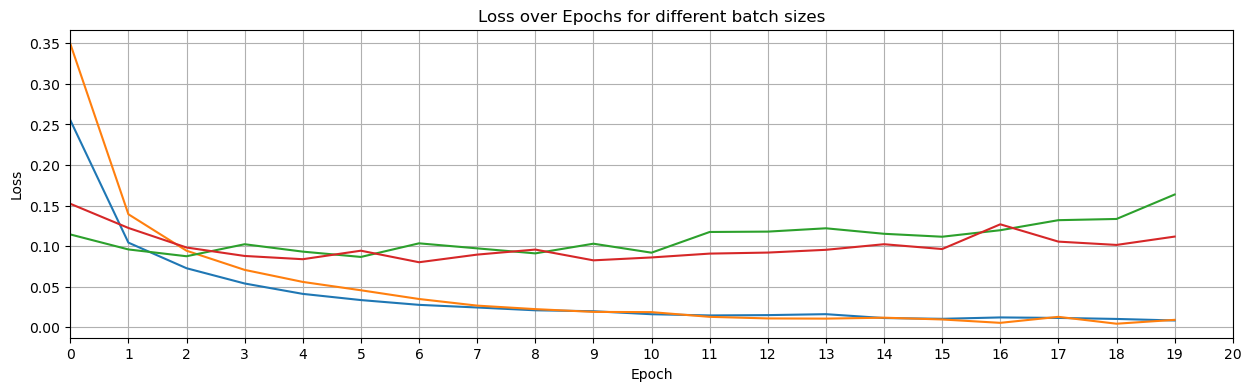

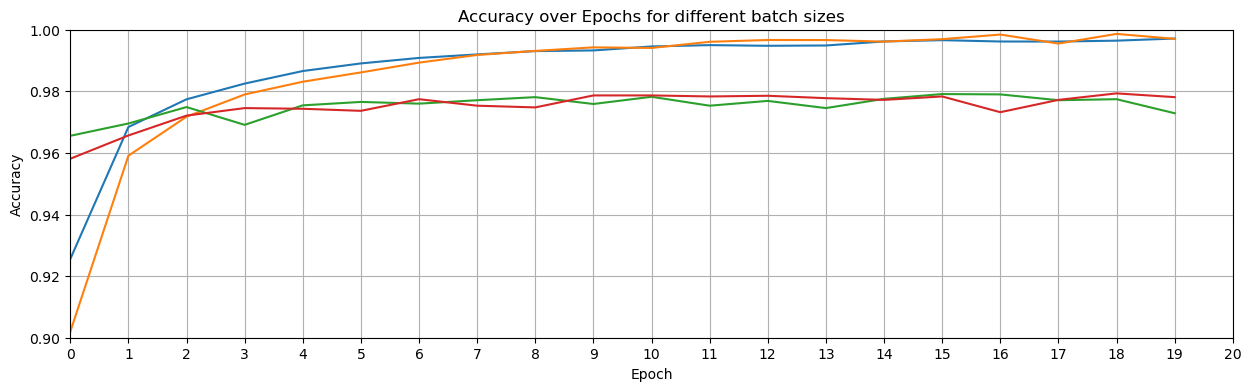

In [19]:
batch_sizes = [32, 128]
results = {}

def build_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(Xtrain.shape[1],)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(
        loss = keras.losses.CategoricalCrossentropy(),
        optimizer = keras.optimizers.Adam(learning_rate=0.001),
        metrics = [keras.metrics.CategoricalAccuracy(name="accuracy")]
    )
    return model

for bs in batch_sizes:
    m = build_model()
    print(f"Training with batch_size={bs}...")
    hist = m.fit(Xtrain, Ytrain, batch_size=bs, epochs=20, validation_split=0.15, verbose=0)
    loss, acc = m.evaluate(Xtest, Ytest, verbose=0)
    results[bs] = {'history': hist.history, 'test_loss': loss, 'test_acc': acc}
    print(f"Batch {bs}: test_accuracy={acc:.4f}")

losses = [results[bs]['history']['loss'] for bs in batch_sizes]
val_losses = [results[bs]['history']['val_loss'] for bs in batch_sizes]
plot_results(
    [results[bs]['history']['loss'] for bs in batch_sizes] + [results[bs]['history']['val_loss'] for bs in batch_sizes],
    title='Loss over Epochs for different batch sizes',
    ylabel='Loss',
    ylim=None,
    metric_name=[f'train bs={bs}' for bs in batch_sizes] + [f'val bs={bs}' for bs in batch_sizes],
    color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray'][:len(batch_sizes)*2]
)

plot_results(
    [results[bs]['history']['accuracy'] for bs in batch_sizes] + [results[bs]['history']['val_accuracy'] for bs in batch_sizes],
    title='Accuracy over Epochs for different batch sizes',
    ylabel='Accuracy',
    ylim=[0.9, 1],
    metric_name=[f'train bs={bs}' for bs in batch_sizes] + [f'val bs={bs}' for bs in batch_sizes],
    color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray'][:len(batch_sizes)*2]
)

print('Final test accuracies:')
for bs in batch_sizes:
    print(f'  batch_size={bs}: test_accuracy={results[bs]["test_acc"]:.4f}')

# Changing Learning Rate

Training with learning_rate=0.0001...
Learning rate 0.0001: test_accuracy=0.9704
Training with learning_rate=0.001...
Learning rate 0.001: test_accuracy=0.9784
Training with learning_rate=0.01...
Learning rate 0.01: test_accuracy=0.9694
Training with learning_rate=0.1...
Learning rate 0.1: test_accuracy=0.1032
Final test accuracies for different learning rates:
  learning_rate=0.0001: test_accuracy=0.9704
  learning_rate=0.001: test_accuracy=0.9784
  learning_rate=0.01: test_accuracy=0.9694
  learning_rate=0.1: test_accuracy=0.1032


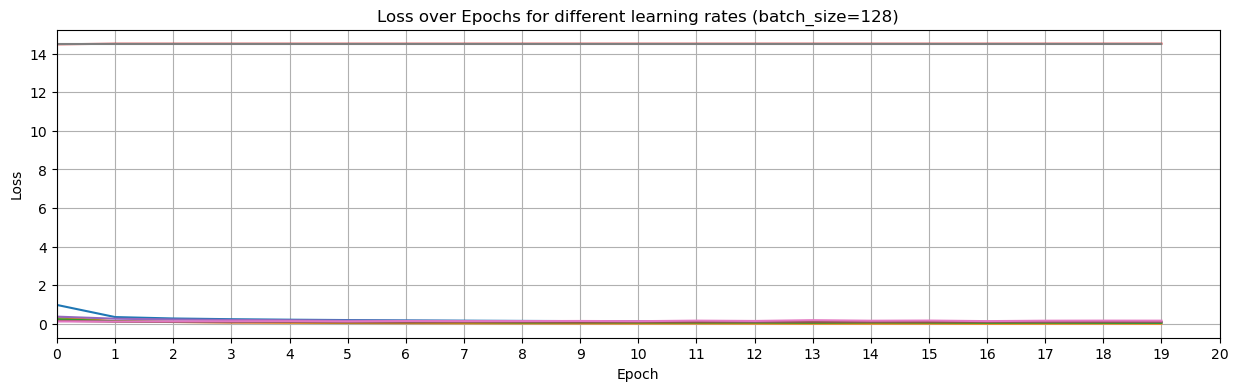

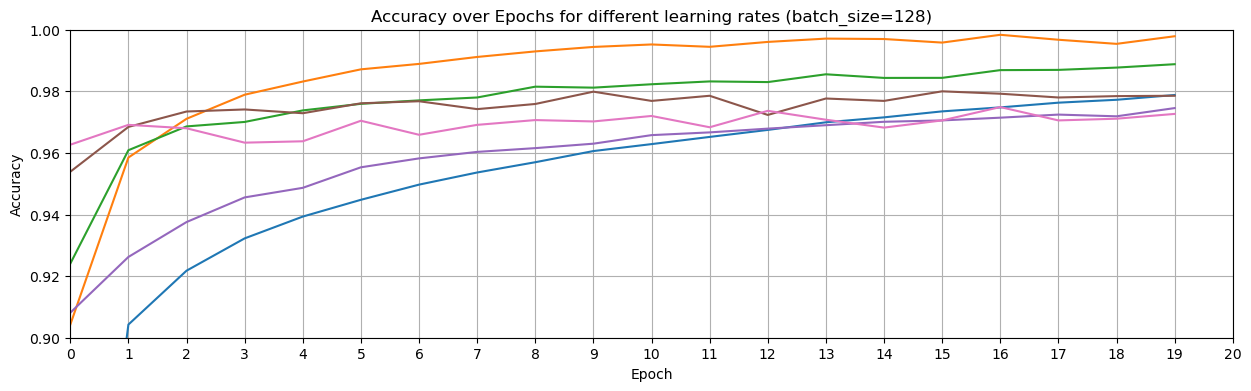

In [22]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
lr_results = {}

def build_model_with_lr(learning_rate):
    model = keras.Sequential([
        keras.layers.Input(shape=(Xtrain.shape[1],)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(
        loss = keras.losses.CategoricalCrossentropy(),
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
        metrics = [keras.metrics.CategoricalAccuracy(name="accuracy")]
    )
    return model

for lr in learning_rates:
    m = build_model_with_lr(lr)
    print(f"Training with learning_rate={lr}...")
    hist = m.fit(Xtrain, Ytrain, batch_size=128, epochs=20, validation_split=0.15, verbose=0)
    loss, acc = m.evaluate(Xtest, Ytest, verbose=0)
    lr_results[lr] = {'history': hist.history, 'test_loss': loss, 'test_acc': acc}
    print(f"Learning rate {lr}: test_accuracy={acc:.4f}")

plot_results(
    [lr_results[lr]['history']['loss'] for lr in learning_rates] + [lr_results[lr]['history']['val_loss'] for lr in learning_rates],
    title='Loss over Epochs for different learning rates (batch_size=128)',
    ylabel='Loss',
    ylim=None,
    metric_name=[f'train lr={lr}' for lr in learning_rates] + [f'val lr={lr}' for lr in learning_rates],
    color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray'][:len(learning_rates)*2]
)

plot_results(
    [lr_results[lr]['history']['accuracy'] for lr in learning_rates] + [lr_results[lr]['history']['val_accuracy'] for lr in learning_rates],
    title='Accuracy over Epochs for different learning rates (batch_size=128)',
    ylabel='Accuracy',
    ylim=[0.9, 1],
    metric_name=[f'train lr={lr}' for lr in learning_rates] + [f'val lr={lr}' for lr in learning_rates],
    color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray'][:len(learning_rates)*2]
)

print('Final test accuracies for different learning rates:')
for lr in learning_rates:
    print(f'  learning_rate={lr}: test_accuracy={lr_results[lr]["test_acc"]:.4f}')

# Varying batch size and learning rate Results
based on the results of different higher batch sizes the model with 128 batch size had slightly higher accuracy and for different learning rates as what we expected model has an optimal learning rate this means that not increasing nor decreasing it will benefit us you can see this in the results learning rate of the model with best accuracy is 0.001. models with higher learning rates like 0.1 not even reached accuracy of 0.5 this why the loss over epochs plot looks funky and because of limiting y-axis the accuracy over epochs plot doesn't contain the result of learning rate 0.1.

# Single Neuron Output

Training MSE model...
Training MAE model...

=== MSE Model ===
Test Loss (MSE): 0.4653
Test MAE: 0.3269

=== MAE Model ===
Test Loss (MAE): 0.2060
Test MAE: 0.2060
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step

=== Accuracy after Rounding ===
MSE Model Accuracy: 0.8508
MAE Model Accuracy: 0.9217

First 10 predictions (MSE model): [2 1 0 4 1 4 8 6 8 0]
First 10 true labels:              [2 1 0 4 1 4 9 5 9 0]


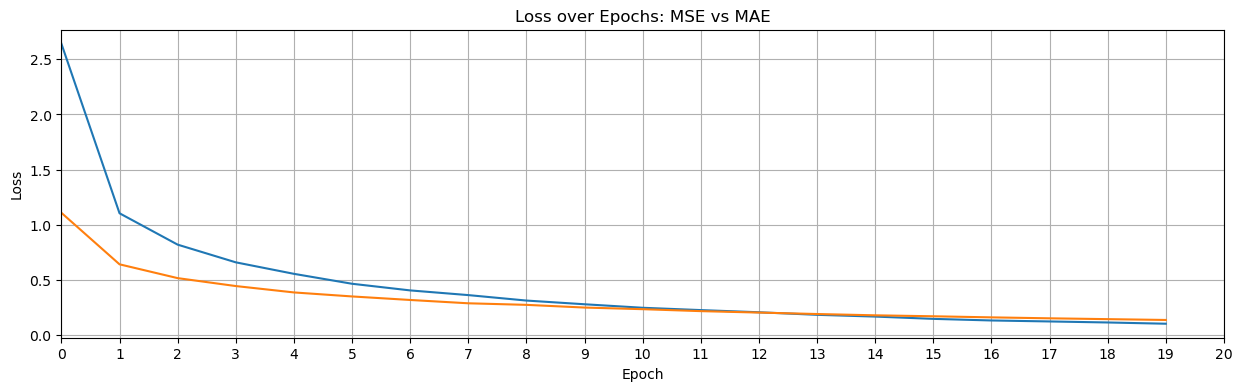

In [18]:
trainData_orig = pd.read_csv("mnist_train.zip")
testData_orig = pd.read_csv("mnist_test.zip")
Ytrain_regression = trainData_orig.iloc[:, 0].to_numpy().astype('float32')
Ytest_regression = testData_orig.iloc[:, 0].to_numpy().astype('float32')



model_regression_mse = keras.Sequential([
    keras.layers.Input(shape=(Xtrain.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1)  # one neuron and no activation function
])
model_regression_mse.compile(
    loss = keras.losses.MeanSquaredError(),  
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    metrics = [keras.metrics.MeanAbsoluteError(name="MAE")]  
)

model_regression_mae = keras.Sequential([
    keras.layers.Input(shape=(Xtrain.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1)
])
model_regression_mae.compile(
    loss = keras.losses.MeanAbsoluteError(),  
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    metrics = [keras.metrics.MeanAbsoluteError(name="MAE")]
)

print("Training MSE model...")
hist_mse = model_regression_mse.fit(Xtrain, Ytrain_regression, batch_size=128, epochs=20, validation_split=0.15, verbose=0)

print("Training MAE model...")
hist_mae = model_regression_mae.fit(Xtrain, Ytrain_regression, batch_size=128, epochs=20, validation_split=0.15, verbose=0)

print("\n=== MSE Model ===")
test_loss_mse, test_mae_mse = model_regression_mse.evaluate(Xtest, Ytest_regression, verbose=0)
print(f"Test Loss (MSE): {test_loss_mse:.4f}")
print(f"Test MAE: {test_mae_mse:.4f}")

print("\n=== MAE Model ===")
test_loss_mae, test_mae_mae = model_regression_mae.evaluate(Xtest, Ytest_regression, verbose=0)
print(f"Test Loss (MAE): {test_loss_mae:.4f}")
print(f"Test MAE: {test_mae_mae:.4f}")

plot_results(
    [hist_mse.history['loss'], hist_mae.history['loss']],
    title='Loss over Epochs: MSE vs MAE',
    ylabel='Loss',
    ylim=None,
    metric_name=['MSE Loss', 'MAE Loss'],
    color=['tab:blue', 'tab:orange']
)

Ypred_mse = model_regression_mse.predict(Xtest)
Ypred_mse_rounded = np.round(Ypred_mse).flatten().astype(int)

Ypred_mae = model_regression_mae.predict(Xtest)
Ypred_mae_rounded = np.round(Ypred_mae).flatten().astype(int)

accuracy_mse = np.mean(Ypred_mse_rounded == Ytest_regression)
accuracy_mae = np.mean(Ypred_mae_rounded == Ytest_regression)

print("\n=== Accuracy after Rounding ===")
print(f"MSE Model Accuracy: {accuracy_mse:.4f}")
print(f"MAE Model Accuracy: {accuracy_mae:.4f}")

print("\nFirst 10 predictions (MSE model):", Ypred_mse_rounded[:10])
print("First 10 true labels:             ", Ytest_regression[:10].astype(int))

# single Neuron Model Results
As you can see the accuracy of single Neuron models with same batch size and learing rate as the catgroical model are much worse than the catgroical model but choosing the loss function like MAE is better than MSE.